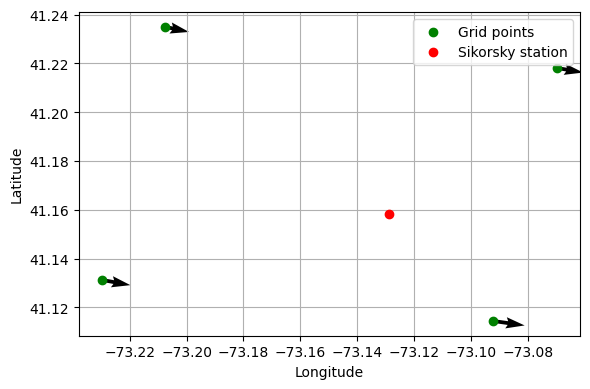

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

ds = xr.open_dataset('netcdf_files/nam_20250601_f001.nc')

# Quiver plot of wind vectors
plt.figure(figsize=(6, 4))
plt.quiver(ds.longitude, ds.latitude, ds.u10, ds.v10)

# Grid points
plt.scatter(ds.longitude, ds.latitude, color='g', label='Grid points')

# Sikorsky location
plt.plot(-73.1289, 41.1583, 'ro', label='Sikorsky station')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
df = pd.read_csv('Sikorsky_fcst.csv')

# Compute WSPD in m/s
df['WSPD'] = np.sqrt(df['u10']**2 + df['v10']**2)
# Compute WDIR in degrees, from true north
df['WDIR'] = (np.degrees(np.arctan2(-df['u10'], -df['v10'])) + 360) % 360

# Compute updated wind components
alpha = -13
theta = -alpha * np.pi / 180
df['u_e'] = df['u10'] * np.cos(theta) + df['v10'] * np.sin(theta)
df['u_n'] = -df['u10'] * np.sin(theta) + df['v10'] * np.cos(theta)

# df.to_csv('Sikorsky_fcst_new.csv', index=False)
df.head()

,TmStamp,u10,v10,WSPD,WDIR,u_e,u_n
0,2024-07-01 00:00:00,0.889252,-2.443201,2.60,340.0,0.316860,-2.580620
1,2024-07-01 01:00:00,2.050000,-3.550704,4.10,330.0,1.198724,-3.920849
2,2024-07-01 02:00:00,1.671248,-1.991716,2.60,320.0,1.180375,-2.316617
3,2024-07-01 03:00:00,-0.000000,-0.250000,0.25,0.0,-0.056238,-0.243593
4,2024-07-01 04:00:00,1.992642,-2.374738,3.10,320.0,1.407371,-2.762120


Mean WSPD error: 0.131
Standard deviation of WSPD error: 1.761


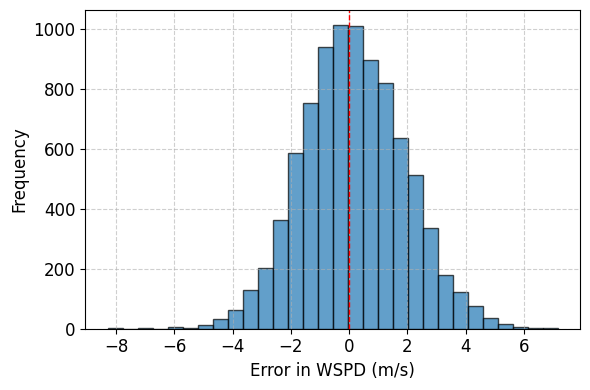

In [3]:
# df_stn: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn = df_stn[df_stn['TmStamp'] > pd.to_datetime('2024-06-30 23:59:00')]

# df_fcst: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
df_fcst = pd.read_csv('Sikorsky_fcst.csv')
df_fcst['TmStamp'] = pd.to_datetime(df_fcst['TmStamp'], format='mixed')

# Compute WSPD error and stats
WSPD_err = df_fcst['WSPD'].values - df_stn['WSPD'].values
print(f'Mean WSPD error: {np.mean(WSPD_err):.3f}')
print(f'Standard deviation of WSPD error: {np.std(WSPD_err, ddof=1):.3f}')

# WSPD error distribution
plt.figure(figsize=(6, 4))
plt.hist(WSPD_err, bins=30, color='#1f77b4', edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Error in WSPD (m/s)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

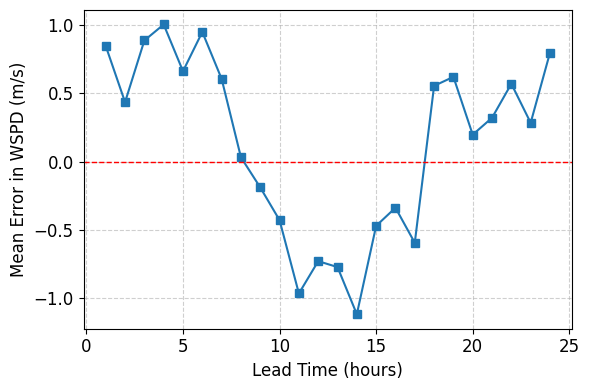

In [4]:
# Reshape into (365 days, 24 hours)
WSPD_err_reshaped = WSPD_err.reshape(365, 24)

# Mean error at each lead time (average over 365 days)
WSPD_mean_err_lead = WSPD_err_reshaped.mean(axis=0)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 25), WSPD_mean_err_lead, color='#1f77b4', marker='s')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Lead Time (hours)', fontsize=12)
plt.ylabel('Mean Error in WSPD (m/s)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Mean WDIR error: -7.031
Standard deviation of WDIR error: 48.524


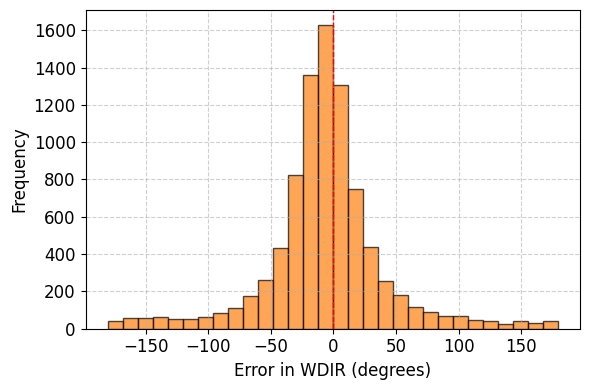

In [5]:
# Compute WDIR error
def circular_error(fcst, obs):
    return (fcst - obs + 180) % 360 - 180

WDIR_err = circular_error(df_fcst['WDIR'].values, df_stn['WDIR'].values)
print(f'Mean WDIR error: {np.mean(WDIR_err):.3f}')
print(f'Standard deviation of WDIR error: {np.std(WDIR_err, ddof=1):.3f}')

# WDIR error distribution
plt.figure(figsize=(6, 4))
plt.hist(WDIR_err, bins=30, color='#ff7f0e', edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Error in WDIR (degrees)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

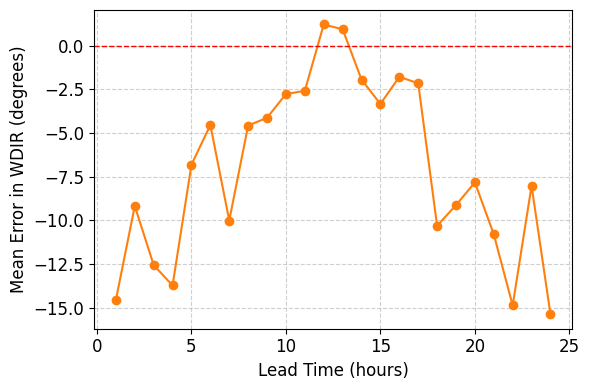

In [6]:
# Reshape into (365 days, 24 hours)
WDIR_err_reshaped = WDIR_err.reshape(365, 24)

# Mean circular error at each lead time (average over 365 days)
WDIR_mean_err_lead = WDIR_err_reshaped.mean(axis=0)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 25), WDIR_mean_err_lead, color='#ff7f0e', marker='o')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Lead Time (hours)', fontsize=12)
plt.ylabel('Mean Error in WDIR (degrees)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()